# Refocusing shuttle noise

Idea: since shuttling noise is all along one axis (Z axis), we can refocus it for the Z ancillae to turn it into an X error. This error will not propagate to the data qubits, so it only manifests as a measurement error on the ancilla (which can be mitigated by doing more measurement rounds). In this notebook, we test whether this works as expected.

In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import sinter
from copy import deepcopy

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode
import src.stim_dag as stim_dag

In [2]:
d = 3
hwp = device.default_hwp
dev = device.UnitCellDevice(d+2, d+2, hwp)
code = RotatedSurfaceCode(d)

sched_default = code.get_schedule(hwp, 'X', 1, False)
sched_refoc = code.get_schedule(hwp, 'X', 1, True)

In [3]:
sched_default.total_duration(), sched_refoc.total_duration()

(7800, 8400)

In [4]:
sched_default.to_stim_circuit(code, 'Z', device.error_params())

stim.Circuit('''
    QUBIT_COORDS(1, 1) 0
    QUBIT_COORDS(1, 3) 1
    QUBIT_COORDS(1, 5) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(3, 3) 4
    QUBIT_COORDS(3, 5) 5
    QUBIT_COORDS(5, 1) 6
    QUBIT_COORDS(5, 3) 7
    QUBIT_COORDS(5, 5) 8
    QUBIT_COORDS(0, 4) 9
    QUBIT_COORDS(2, 0) 10
    QUBIT_COORDS(2, 2) 11
    QUBIT_COORDS(2, 4) 12
    QUBIT_COORDS(4, 2) 13
    QUBIT_COORDS(4, 4) 14
    QUBIT_COORDS(4, 6) 15
    QUBIT_COORDS(6, 2) 16
    R 0 1 2 3 4 5 6 7 8
    X_ERROR(0.001) 0 1 2 3 4 5 6 7 8
    H 0 1 2 3 4 5 6 7 8
    DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8
    Z_ERROR(1e-06) 0 1 2 3 4 5 6 7 8
    R 10 12 13 15 9 11 14 16
    X_ERROR(0.001) 10 12 13 15 9 11 14 16
    H 10 12 13 15
    DEPOLARIZE1(0.001) 10 12 13 15
    Z_ERROR(1e-06) 10 12 13 15 14 11 9 16
    Z_ERROR(0.00697556) 7
    CX 13 7
    DEPOLARIZE2(0.001) 13 7
    CX 12 5
    DEPOLARIZE2(0.001) 12 5
    CX 10 3
    DEPOLARIZE2(0.001) 10 3
    CX 2 9
    DEPOLARIZE2(0.001) 2 9
    CX 4 11
    DEPOLARIZE2(0.001) 4 1

In [13]:
rs = list(range(1,10))
p_shs = np.geomspace(1e-3, 1e-1, 7)
tasks = []
for r in rs:
    # sched_default_X = code.get_schedule(hwp, 'X', r, False)
    # sched_refoc_X = code.get_schedule(hwp, 'X', r, True)
    sched_default_Z = code.get_schedule(hwp, 'Z', r, False)
    sched_refoc_Z = code.get_schedule(hwp, 'Z', r, True)
    for p_sh in p_shs:
        # ep = device.ErrorParams(
        #     T2=float('inf'),
        #     cx_err=0,
        #     h_err=0,
        #     shuttle_err=p_sh,
        #     emplace_err=0,
        #     init_err=0,
        #     measure_err=0,
        # )
        ep = device.error_params(1e-3, 0.01, p_sh)
        circ = sched_default_Z.to_stim_circuit(code, 'X', ep)
        print(len(circ), end=', ')
        circ = stim_dag.simplify_circ(circ)
        print(len(circ))
        tasks.append(sinter.Task(
            circuit=circ,
            json_metadata={'refoc':False, 'r':r, 'p_sh':p_sh, 'basis':'X'}
        ))
        circ = sched_refoc_Z.to_stim_circuit(code, 'X', ep)
        print(len(circ), end=', ')
        circ = stim_dag.simplify_circ(circ)
        print(len(circ))
        tasks.append(sinter.Task(
            circuit=circ,
            json_metadata={'refoc':True, 'r':r, 'p_sh':p_sh, 'basis':'X'}
        ))
        circ = sched_default_Z.to_stim_circuit(code, 'Z', ep)
        print(len(circ), end=', ')
        circ = stim_dag.simplify_circ(circ)
        print(len(circ))
        tasks.append(sinter.Task(
            circuit=circ,
            json_metadata={'refoc':False, 'r':r, 'p_sh':p_sh, 'basis':'Z'}
        ))
        circ = sched_refoc_Z.to_stim_circuit(code, 'Z', ep)
        print(len(circ), end=', ')
        circ = stim_dag.simplify_circ(circ)
        print(len(circ))
        tasks.append(sinter.Task(
            circuit=circ,
            json_metadata={'refoc':True, 'r':r, 'p_sh':p_sh, 'basis':'Z'}
        ))

Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
111, 66
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
151, 102
107, 64
147, 100
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
111, 66
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
151, 102
107, 64
147, 100
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
111, 66
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
151, 102
107, 64
147, 100
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
111, 66
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
151, 102
107, 64
147, 100
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
111, 66
C

In [14]:
stats = sinter.collect(tasks=tasks, num_workers=6, decoders='pymatching', max_shots=10**6, max_errors=500, print_progress=True)

Starting 6 workers...
252 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                                     
        1 pymatching   ?    1000000         500 refoc=False,r=1,p_sh=0.001,basis=X                
        1 pymatching   ?    1000000         500 refoc=True,r=1,p_sh=0.001,basis=X                 
        1 pymatching   ?    1000000         500 refoc=False,r=1,p_sh=0.001,basis=Z                
        1 pymatching   ?    1000000         500 refoc=True,r=1,p_sh=0.001,basis=Z                 
        1 pymatching   ?    1000000         500 refoc=False,r=1,p_sh=0.0021544346900318843,basis=X
        1 pymatching <1m     902447         431 refoc=True,r=1,p_sh=0.0021544346900318843,basis=X 
        0 pymatching ?·∞    1000000         500 refoc=False,r=1,p_sh=0.0021544346900318843,basis=Z
        0 pymatching ?·∞    1000000         500 refoc=True,r=1,p_sh=0.0021544346900318843,basis=Z 
        0 pymatching ?·∞    1000000         500 refoc=False,r=1,p_sh=0.

In [15]:
combined_stats = []
for stat in stats:
    md = stat.json_metadata
    if md['basis'] == 'X':
        continue
    matching_stat = None
    for stat_other in stats:
        match_fail = False
        for k,v in md.items():
            if k != 'basis' and stat_other.json_metadata[k] != v:
                match_fail = True
            if k == 'basis' and stat_other.json_metadata[k] == v:
                match_fail = True
        if match_fail:
            continue
        matching_stat = stat_other
        break
    assert matching_stat

    shots_combined = max(stat.shots, matching_stat.shots)
    errors_combined = round((1 - (1 - stat.errors / stat.shots) * (1 - matching_stat.errors / matching_stat.shots)) * shots_combined)
    combined_stats.append(sinter.TaskStats(
        strong_id=stat.strong_id,
        decoder=stat.decoder,
        json_metadata={k:v for k,v in stat.json_metadata.items() if k != 'basis'},
        shots=shots_combined,
        errors=errors_combined,
    ))

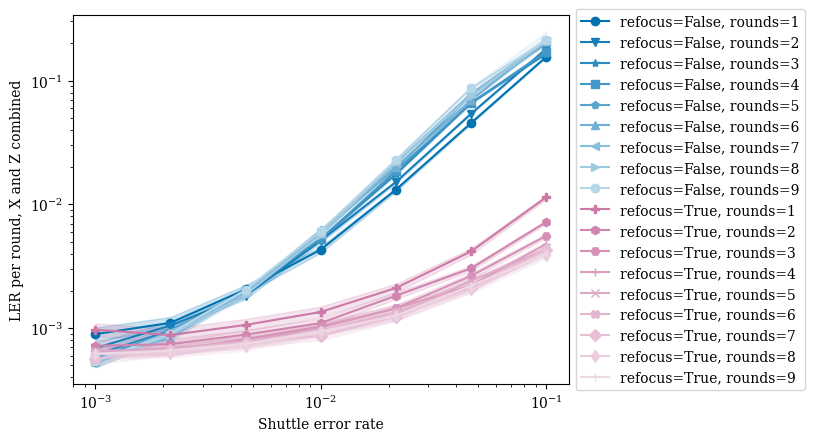

In [16]:
fig,ax = plt.subplots()
sinter.plot_error_rate(
    ax=ax,
    stats=combined_stats,
    x_func=lambda s: s.json_metadata['p_sh'],
    group_func=lambda s: f"refocus={s.json_metadata['refoc']}, rounds={s.json_metadata['r']}",
    failure_units_per_shot_func=lambda s: s.json_metadata['r'],
    plot_args_func=lambda i,key,stats: {'color':plotter.interpolate('C0' if 'False' in key else 'C1', 'w', 0.8*(int(key.split('=')[-1])-1) / 9 + 0.0)},
)
plt.loglog()
# leg.remove()
handles, labels = ax.get_legend_handles_labels()
sorted_indices = sorted(range(len(labels)), key=lambda i: labels[i])
ax.legend([handles[i] for i in sorted_indices], [labels[i] for i in sorted_indices], bbox_to_anchor=(1, 0.5), loc='center left')
plt.xlabel('Shuttle error rate')
plt.ylabel('LER per round, X and Z combined')
plt.show()

In [17]:
d = 3
tasks_surface = [
    sinter.Task(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=r,
            distance=d,
            before_round_data_depolarization=alpha*1e-2,
            before_measure_flip_probability=(1-alpha)*1e-2,
        ),
        json_metadata={'d': d, 'a': alpha, 'r':r},
    )
    for r in [1,2,3, 4, 5, 6, 7]
    for alpha in np.linspace(0, 1, 7)
]

collected_stats = sinter.collect(
    num_workers=4,
    tasks=tasks_surface,
    decoders=['pymatching'],
    max_shots=100_0000,
    max_errors=500,
)

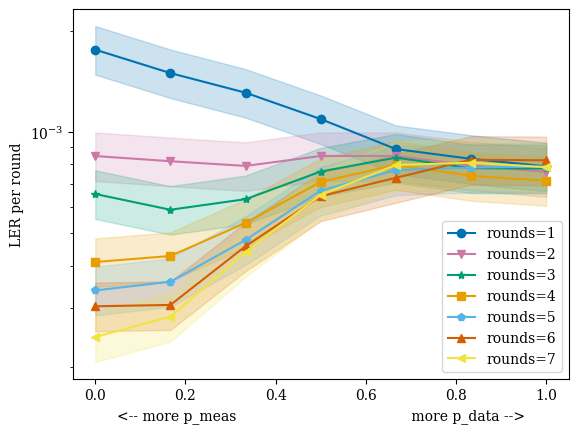

In [18]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['a'],
    group_func=lambda stats: stats.json_metadata['r'],
    failure_units_per_shot_func=lambda stats: stats.json_metadata['r'],
    plot_args_func=lambda i,key,s: {'label':f'rounds={key}'},
)
plt.legend()
plt.yscale('log')
plt.xlabel('<-- more p_meas                                        more p_data -->')
plt.ylabel('LER per round')
plt.show()

In [19]:
d = 3
ps = np.geomspace(1e-3, 1e-1, 7)
tasks_surface = [
    sinter.Task(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=r,
            distance=d,
            before_measure_flip_probability=p,
        ),
        json_metadata={'d': d, 'p': p, 'r':r, 'error':'meas'},
    )
    for r in [1,2,3, 4, 5, 6, 7]
    for p in ps
] + [
    sinter.Task(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=r,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={'d': d, 'p': p, 'r':r, 'error':'data'},
    )
    for r in [1,2,3, 4, 5, 6, 7]
    for p in ps
]

collected_stats = sinter.collect(
    num_workers=4,
    tasks=tasks_surface,
    decoders=['pymatching'],
    max_shots=100_0000,
    max_errors=500,
)

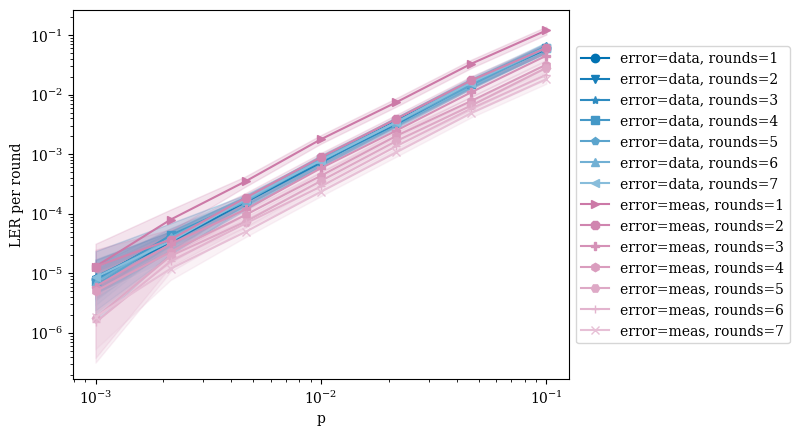

In [20]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: f"error={stats.json_metadata['error']}, rounds={stats.json_metadata['r']}",
    failure_units_per_shot_func=lambda stats: stats.json_metadata['r'],
    plot_args_func=lambda i,key,s: {'color':plotter.interpolate('C0' if 'data' in key else 'C1', 'w', 0.8*(int(key.split('=')[-1])-1) / 9 + 0.0)},
)
handles, labels = ax.get_legend_handles_labels()
sorted_indices = sorted(range(len(labels)), key=lambda i: labels[i])
ax.legend([handles[i] for i in sorted_indices], [labels[i] for i in sorted_indices], bbox_to_anchor=(1, 0.5), loc='center left')
plt.loglog()
plt.xlabel('p')
plt.ylabel('LER per round')
plt.show()